# 02 — Análise Exploratória de Dados (EDA)
**Projeto:** Give Me Some Credit — Classificação de Risco de Crédito  
**Notebook:** `02_analise_exploratoria.ipynb`  
**Autor:** Eduardo EMF  
**Repositório:** [credit-risk-classifier](https://github.com/eduardoemf/credit-risk-classifier)

---

## 🎯 Objetivo

O objetivo deste projeto é prever a probabilidade de um cliente enfrentar dificuldades financeiras nos próximos dois anos, apoiando decisões de concessão de crédito.

Este notebook realiza a **Análise Exploratória de Dados (EDA)** após a limpeza executada em `01_data_cleaning.ipynb`. A partir de um dataset consistente — com nomes padronizados, valores faltantes tratados, inconsistências corrigidas e caps aplicados — vamos investigar distribuições, padrões e relações entre variáveis.

**Perguntas que guiam esta análise:**
- Qual é o perfil dos clientes inadimplentes?
- Quais variáveis apresentam maior poder discriminativo?
- Existe multicolinearidade que possa comprometer a modelagem?
- Que padrões de comportamento financeiro antecipam o default?

---

## 📘 Dicionário de Dados

| Variável | Tipo | Descrição |
|---|---|---|
| `target_default_2y` | Binária | Inadimplência séria nos próximos 2 anos (1 = inadimplente, 0 = adimplente) |
| `revolving_utilization` | Contínua | Proporção de uso das linhas de crédito rotativo não garantidas (0 a 1) |
| `age` | Contínua | Idade do cliente em anos |
| `debt_ratio` | Contínua | Relação entre despesas mensais e renda mensal |
| `monthly_income` | Contínua | Renda mensal do cliente |
| `num_credit_lines` | Discreta | Número total de linhas de crédito e empréstimos em aberto |
| `num_real_estate_loans` | Discreta | Número de empréstimos imobiliários ativos |
| `late_30_59_days` | Discreta | Nº de vezes com atraso entre 30 e 59 dias (últimos 2 anos) |
| `late_60_89_days` | Discreta | Nº de vezes com atraso entre 60 e 89 dias (últimos 2 anos) |
| `late_90_plus_days` | Discreta | Nº de vezes com atraso ≥ 90 dias (últimos 2 anos) |
| `num_dependents` | Discreta | Número de dependentes na família (excluindo cônjuge) |

---

## ⚙️ Configuração do Ambiente

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest
from scipy.cluster.hierarchy import linkage, dendrogram

# ── Opções de exibição ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# ── Tema visual padronizado ─────────────────────────────────────────
# especificação da paleta
PALETTE_MAIN   = 'steelblue'
PALETTE_TARGET = {0: '#5b9bd5', 1: '#d9534f'}   # Azul = adimplente | Vermelho = inadimplente
PALETTE_HEATMAP = 'coolwarm'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

---

## 1. Carregamento e Visão Geral dos Dados

In [2]:
# Dados processados no notebook de limpeza
df = pd.read_parquet('../data/processed/cs-training_cleaned.parquet')

> 💾 Leitura a partir do arquivo `.parquet` gerado em `01_data_cleaning.ipynb`.  
> O formato Parquet preserva tipos de dados e garante leitura eficiente.

In [3]:
# Dimensões do dataset
df.shape

(149999, 11)

> O número de linhas representa os registros disponíveis para análise; o número de colunas corresponde às variáveis mantidas após limpeza.

In [4]:
# Tipos de dados e completude
df.info()

<class 'pandas.DataFrame'>
Index: 149999 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      149999 non-null  int64  
 1   revolving_utilization  149999 non-null  float64
 2   age                    149999 non-null  int64  
 3   debt_ratio             149999 non-null  float64
 4   monthly_income         149999 non-null  float64
 5   num_credit_lines       149999 non-null  int64  
 6   late_30_59_days        149999 non-null  int64  
 7   late_60_89_days        149999 non-null  int64  
 8   late_90_plus_days      149999 non-null  int64  
 9   num_real_estate_loans  149999 non-null  int64  
 10  num_dependents         149999 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 13.7 MB


> Confirmamos tipos consistentes e ausência de `NaN` nas variáveis tratadas no pipeline anterior.

In [5]:
# Verificação de valores faltantes remanescentes (%)
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0] if missing.any() else "✅ Nenhum valor faltante encontrado.")

✅ Nenhum valor faltante encontrado.


In [6]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target_default_2y,149999.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
revolving_utilization,149999.00,0.32,0.35,0.00,0.03,0.15,0.56,1.00
age,149999.00,52.30,14.77,21.00,41.00,52.00,63.00,109.00
debt_ratio,149999.00,316.55,906.97,0.00,0.18,0.37,0.87,4979.08
monthly_income,149999.00,6142.45,3835.69,0.00,3903.00,5400.00,7400.00,23000.00
num_credit_lines,149999.00,8.43,5.03,0.00,5.00,8.00,11.00,27.00
late_30_59_days,149999.00,0.25,0.70,0.00,0.00,0.00,0.00,5.00
late_60_89_days,149999.00,0.07,0.33,0.00,0.00,0.00,0.00,3.00
late_90_plus_days,149999.00,0.09,0.45,0.00,0.00,0.00,0.00,4.00
num_real_estate_loans,149999.00,1.01,1.04,0.00,0.00,1.00,2.00,6.00


> As estatísticas descritivas confirmam que os caps aplicados no data cleaning foram efetivos.  
> Também revelam a escala das variáveis — relevante para normalização na etapa de modelagem.

---

## 2. Distribuições Univariadas

Nesta seção analisamos cada variável de forma isolada, buscando identificar o comportamento típico, presença de outliers e eventuais assimetrias que possam orientar transformações.

### 2.1 Variáveis Contínuas

Variáveis com escala numérica não limitada a inteiros:

- `revolving_utilization`  
- `debt_ratio`  
- `monthly_income`  
- `age`

In [7]:
def plot_continuous(df, column):
    """
    Gera histograma, KDE e boxplot para análise univariada de variável contínua.

    Args:
        df (pd.DataFrame): DataFrame com os dados.
        column (str): Coluna a ser analisada.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df[column], kde=False, ax=axes[0], color=PALETTE_MAIN)
    axes[0].set_title(f'Histograma — {column}', fontsize=13)
    axes[0].set_xlabel('')

    sns.kdeplot(df[column], ax=axes[1], fill=True, color=PALETTE_MAIN, alpha=0.7)
    axes[1].set_title(f'Densidade (KDE) — {column}', fontsize=13)
    axes[1].set_xlabel('')

    sns.boxplot(x=df[column], ax=axes[2], color='lightsteelblue')
    axes[2].set_title(f'Boxplot (Outliers) — {column}', fontsize=13)
    axes[2].set_xlabel('')

    plt.suptitle(f'Análise Univariada: {column}', fontsize=14, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

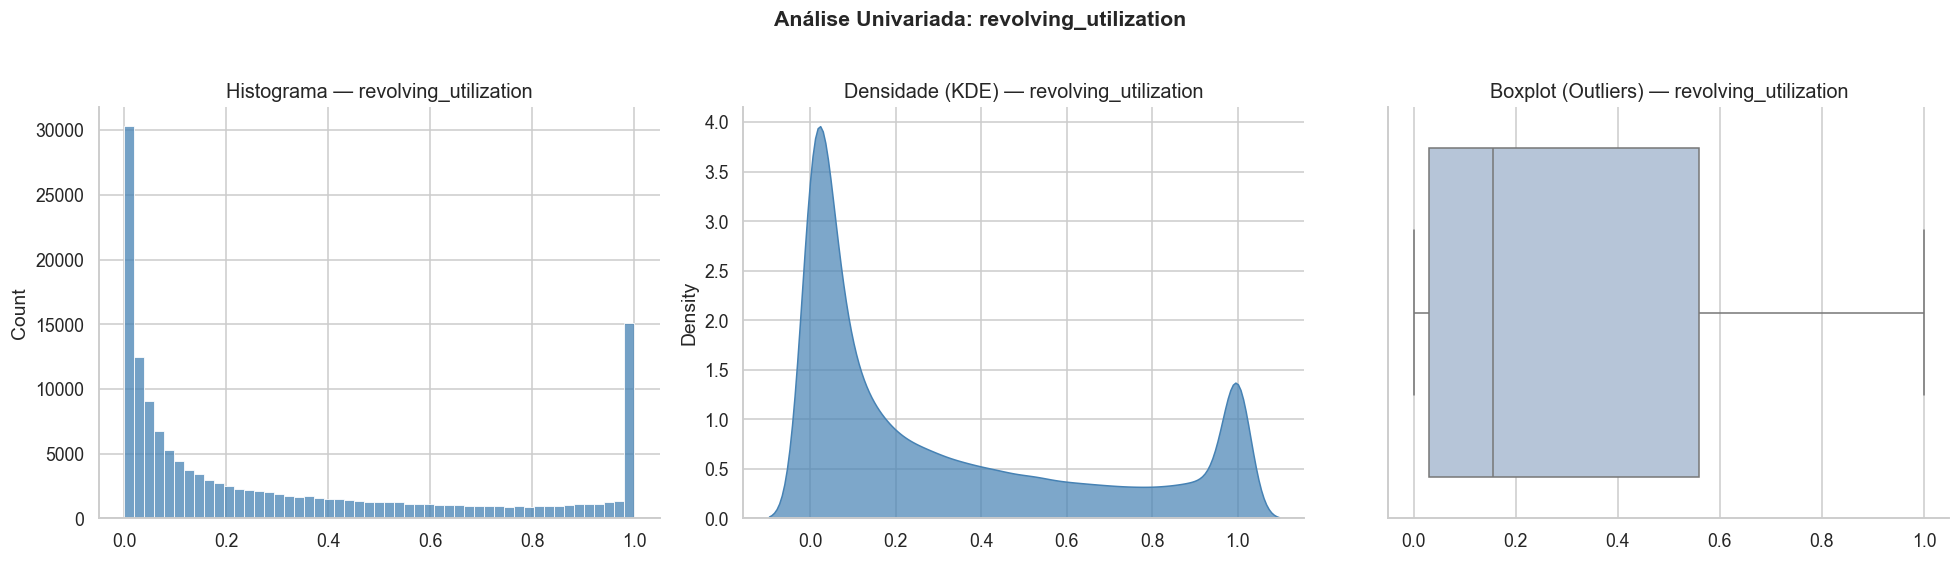

In [8]:
plot_continuous(df, 'revolving_utilization')

> **🔍 Insight:** A utilização do crédito rotativo está fortemente concentrada em valores próximos de 0 — a maioria dos clientes usa pouco do limite disponível.  
> Entretanto, há um grupo relevante com utilização próxima a 1,0, sinalizando esgotamento do limite disponível — comportamento classicamente associado a alto risco de crédito.  
> A mediana baixa combinada com dispersão elevada no boxplot reforça que esta variável carregará poder discriminativo significativo na modelagem.

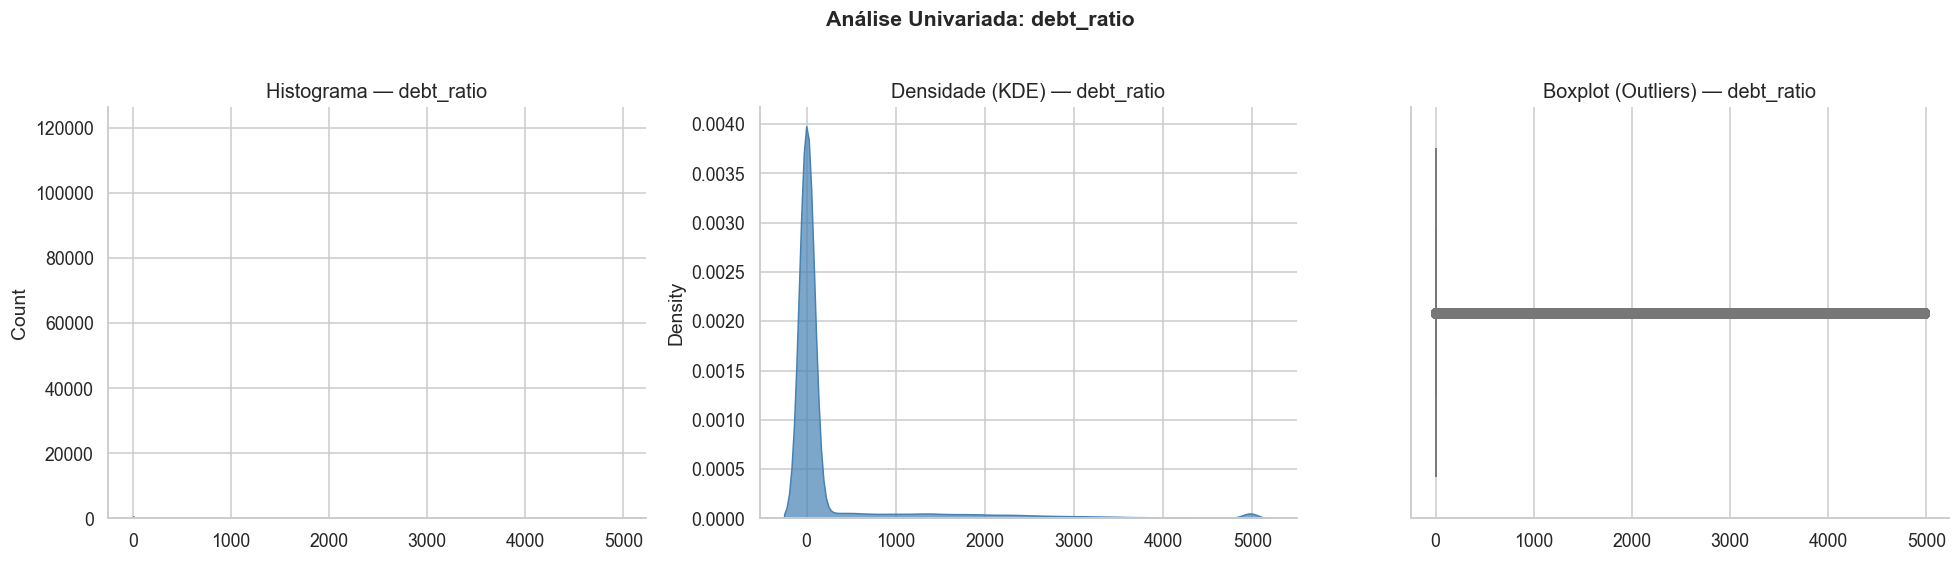

In [9]:
plot_continuous(df, 'debt_ratio')

> **🔍 Insight:** Distribuição com cauda longa à direita. Valores acima de 1,0 indicam que as despesas mensais superam a renda — sinal crítico de potencial insolvência.  
> O cap aplicado na limpeza conteve os extremos, mas a assimetria persiste e deve ser monitorada na modelagem.

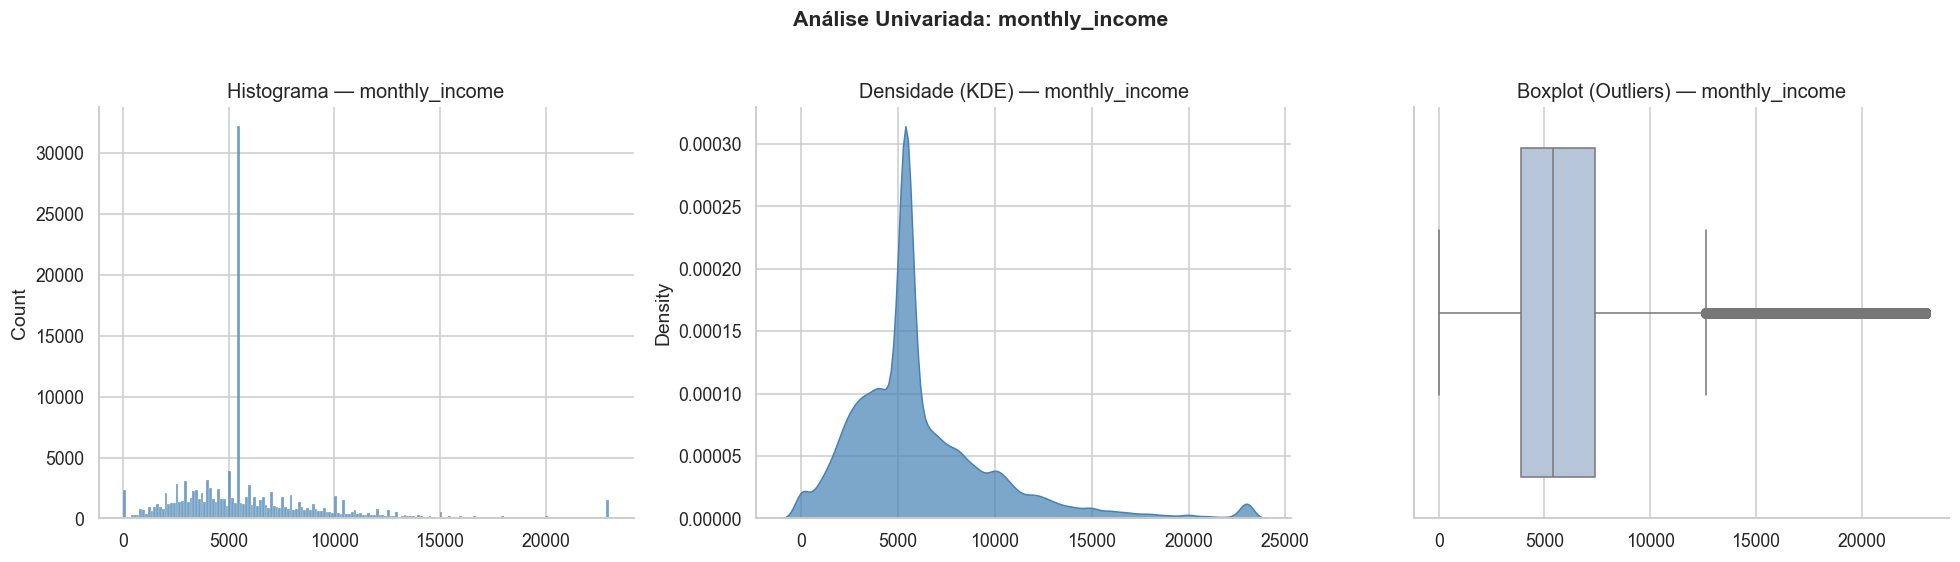

In [10]:
plot_continuous(df, 'monthly_income')

> **🔍 Insight:** Concentração entre ~2k–7k com pico próximo de 5k e cauda longa à direita, típica de variáveis de renda.  
> O boxplot evidencia outliers superiores — indivíduos com renda muito acima da mediana. Transformação logarítmica pode ser útil na modelagem.

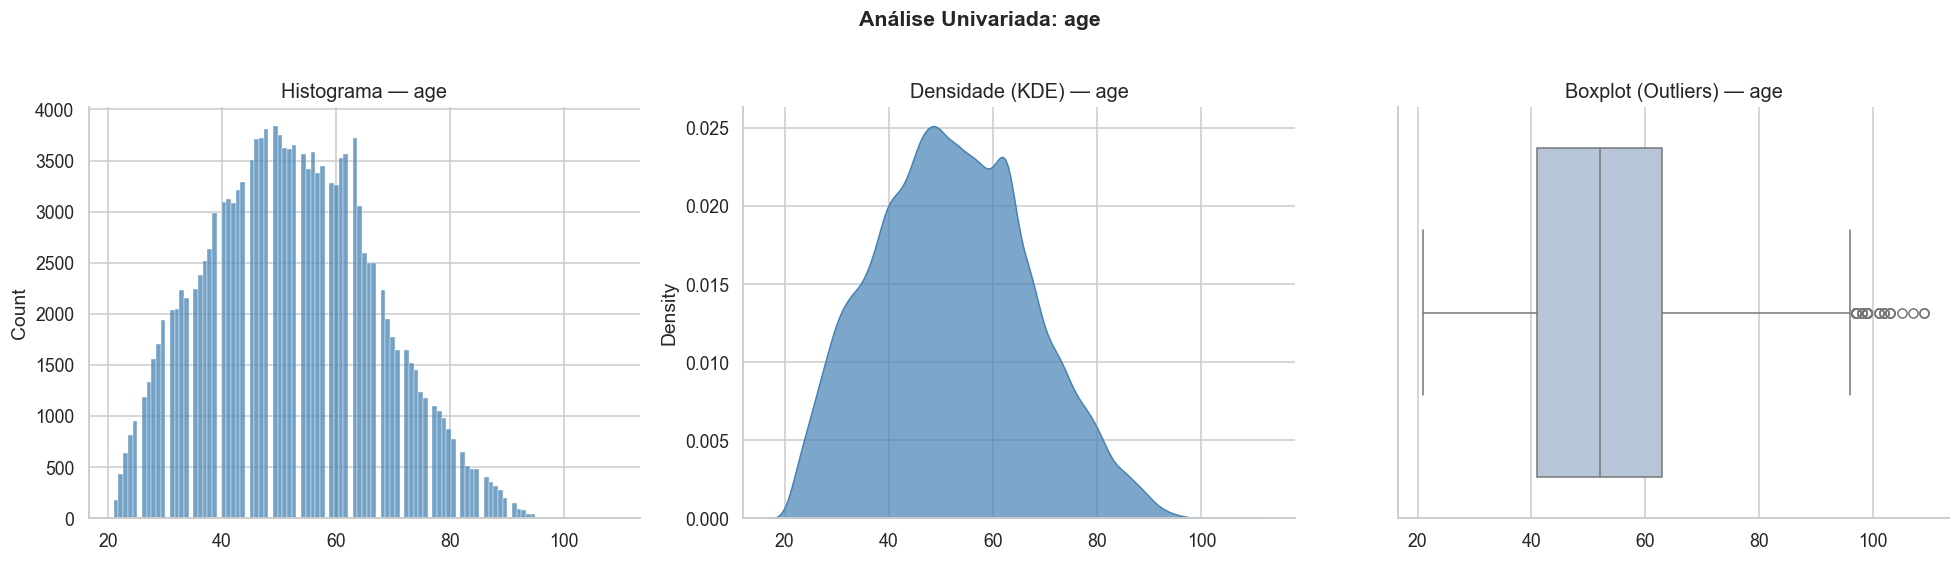

In [11]:
plot_continuous(df, 'age')

> **🔍 Insight:** Distribuição quase unimodal com maior concentração entre 40–60 anos. Assimetria leve e outliers superiores (idades muito elevadas).  
> Padrão esperado para uma base de solicitantes de crédito com perfil demograficamente ativo.

---

### 2.2 Variáveis Discretas

Variáveis com valores inteiros e número limitado de categorias:

- `num_credit_lines`  
- `num_real_estate_loans`  
- `late_30_59_days`  
- `late_60_89_days`  
- `late_90_plus_days`  
- `num_dependents`

In [12]:
def plot_count(df, column, title_name: str = None):
    """
    Gera gráfico de barras de frequência absoluta para variável discreta.

    Args:
        df (pd.DataFrame): DataFrame com os dados.
        column (str): Coluna a ser visualizada.
        title_name (str, optional): Rótulo customizado para o eixo/título.
    """
    label_name = title_name if title_name else column

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=df, x=column, color=PALETTE_MAIN, ax=ax)

    ax.set_title(f'Distribuição de Frequência: {label_name}', fontsize=14, pad=15)
    ax.set_xlabel(label_name, fontsize=12)
    ax.set_ylabel('Quantidade de Registros', fontsize=12)
    plt.xticks(rotation=45)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

    zeros = (df[column] == 0).mean() * 100
    print(f"💡 {label_name}: {zeros:.2f}% dos registros possuem valor zero.")

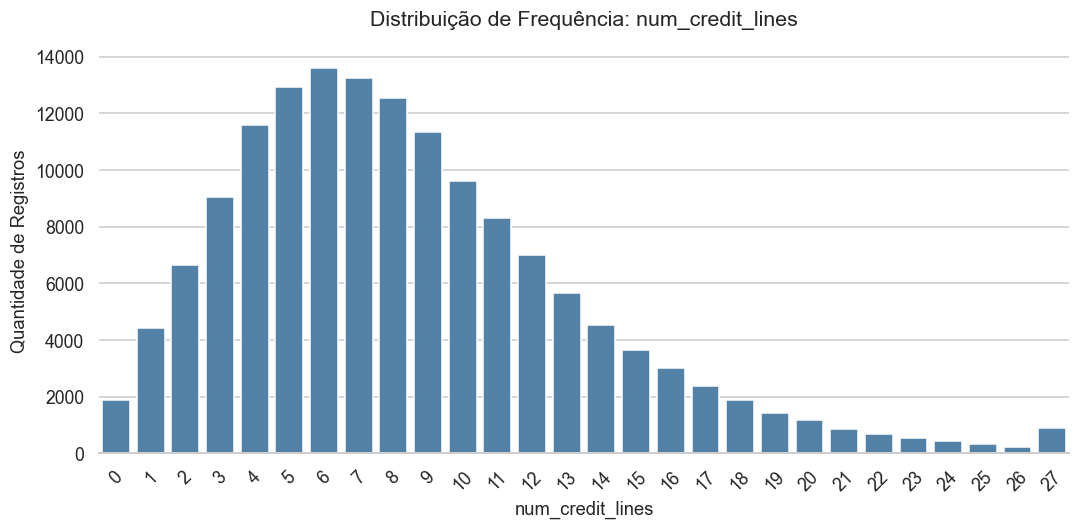

💡 num_credit_lines: 1.26% dos registros possuem valor zero.


In [13]:
plot_count(df, 'num_credit_lines')

> **🔍 Insight:** Distribuição assimétrica à direita com pico entre 6–7 linhas. A maior parte dos clientes mantém um número moderado de contas ativas.  
> Não há sinal de diferenciação óbvia pelo volume total de linhas; a análise bivariada confirmará se há poder discriminativo.

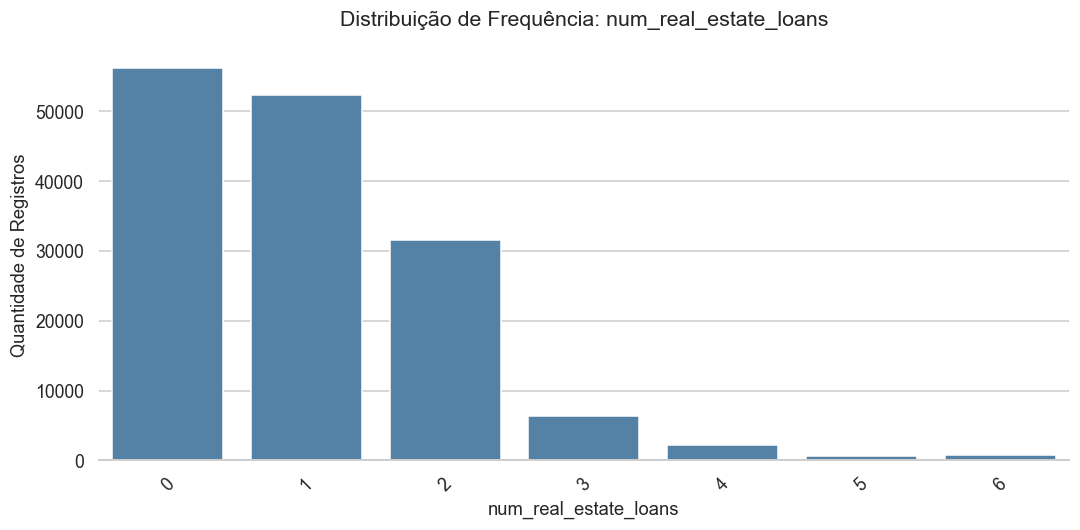

💡 num_real_estate_loans: 37.46% dos registros possuem valor zero.


In [14]:
plot_count(df, 'num_real_estate_loans')

> **🔍 Insight:** Predominância de 0 ou 1 empréstimo imobiliário, comportamento esperado dado o custo e compromisso desse tipo de dívida.  
> Variável com baixa variabilidade — pode ter impacto limitado como preditor isolado.

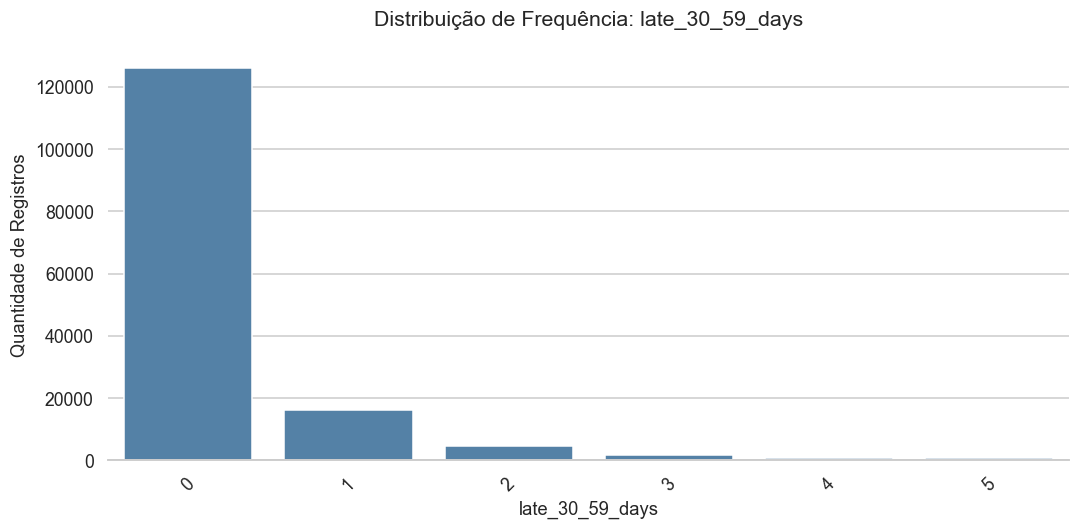

💡 late_30_59_days: 84.01% dos registros possuem valor zero.


In [15]:
plot_count(df, 'late_30_59_days')

> **🔍 Insight:** Concentração extrema em zero — a grande maioria dos clientes nunca apresentou atraso entre 30 e 59 dias.  
> Apesar da alta esparsidade, a presença de qualquer valor acima de 0 é um sinal relevante de comportamento de risco.

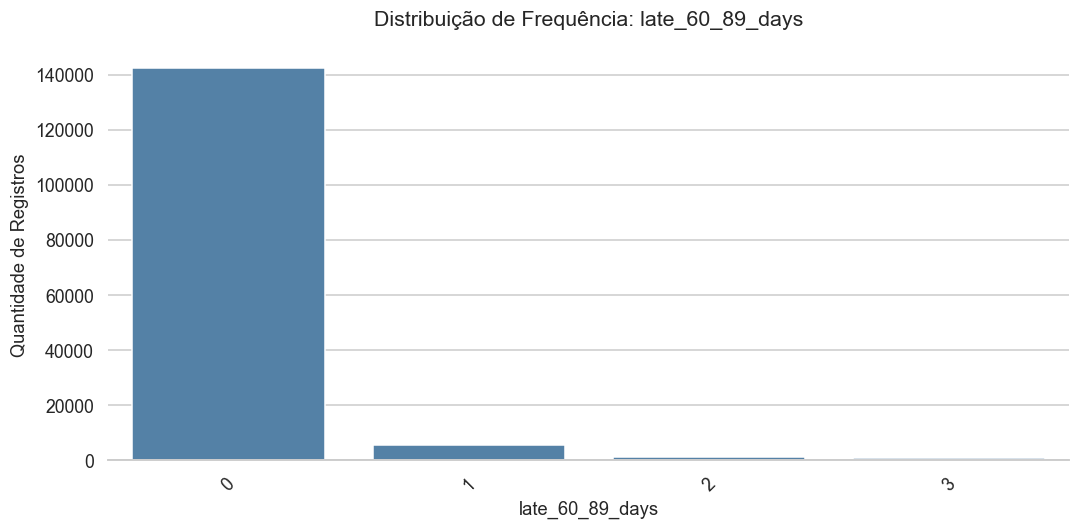

💡 late_60_89_days: 94.93% dos registros possuem valor zero.


In [16]:
plot_count(df, 'late_60_89_days')

> **🔍 Insight:** Distribuição ainda mais concentrada em zero do que `late_30_59_days` (>94% zeros).  
> Atrasos nessa faixa representam inadimplência já elevada — mesmo raros, tendem a exercer grande peso na modelagem.

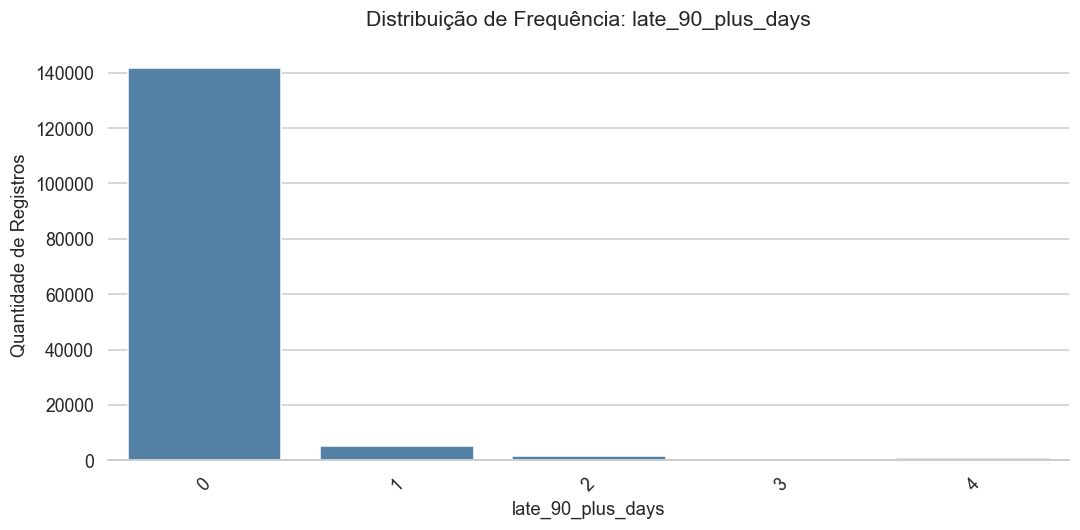

💡 late_90_plus_days: 94.44% dos registros possuem valor zero.


In [17]:
plot_count(df, 'late_90_plus_days')

> **🔍 Insight:** Variável mais esparsa entre as três de atraso. Atrasos acima de 90 dias caracterizam inadimplência severa.  
> Apesar da raridade, deve ser um dos preditores mais fortes do modelo — confirmaremos na análise de correlação.

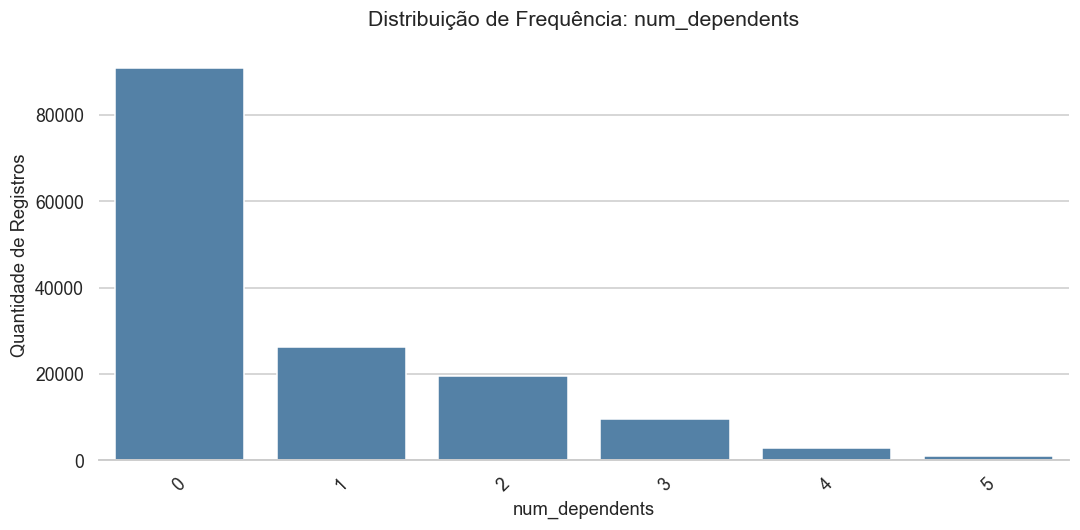

💡 num_dependents: 60.55% dos registros possuem valor zero.


In [18]:
plot_count(df, 'num_dependents')

> **🔍 Insight:** ~60% dos clientes não possuem dependentes. A frequência diminui gradualmente com o aumento do número.  
> Um maior número de dependentes pode comprometer a folga orçamentária, mas o sinal precisa ser verificado na análise bivariada.

---

## 3. Análise da Variável-Alvo

Antes de qualquer análise bivariada, é fundamental compreender a distribuição da variável a ser predita.

In [19]:
# Distribuição absoluta e relativa
counts = df['target_default_2y'].value_counts()
props  = df['target_default_2y'].value_counts(normalize=True).mul(100).round(2)

print("Contagem absoluta:")
print(counts)
print()
print("Proporção (%):")
print(props)

Contagem absoluta:
target_default_2y
0    139973
1     10026
Name: count, dtype: int64

Proporção (%):
target_default_2y
0   93.32
1    6.68
Name: proportion, dtype: float64


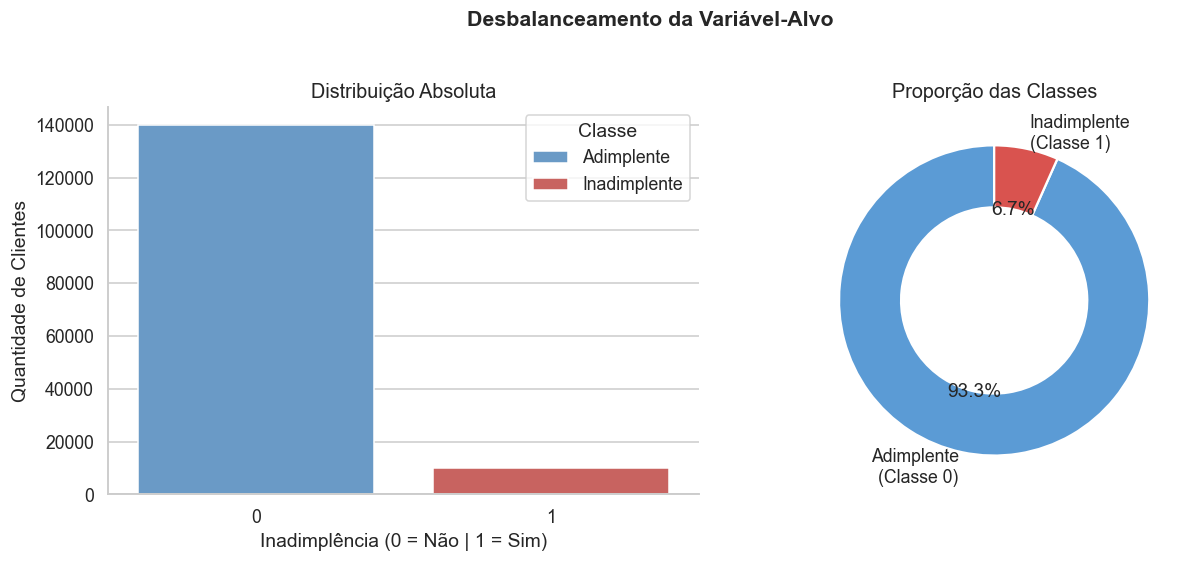

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem absoluta
sns.countplot(data=df, x='target_default_2y', palette=PALETTE_TARGET, ax=axes[0], hue='target_default_2y', legend=False)
axes[0].set_title('Distribuição Absoluta', fontsize=13)
axes[0].set_xlabel('Inadimplência (0 = Não | 1 = Sim)')
axes[0].set_ylabel('Quantidade de Clientes')
axes[0].legend(handles=axes[0].patches, labels=['Adimplente', 'Inadimplente'], title='Classe')

# Proporção percentual
labels = ['Adimplente\n(Classe 0)', 'Inadimplente\n(Classe 1)']
sizes  = df['target_default_2y'].value_counts(normalize=True).values * 100
colors = [PALETTE_TARGET[0], PALETTE_TARGET[1]]
axes[1].pie(
            sizes, 
            labels=labels, 
            colors=colors, 
            autopct='%1.1f%%',
            startangle=90, 
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1.5)
            )
axes[1].set_title('Proporção das Classes', fontsize=13)

plt.suptitle('Desbalanceamento da Variável-Alvo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

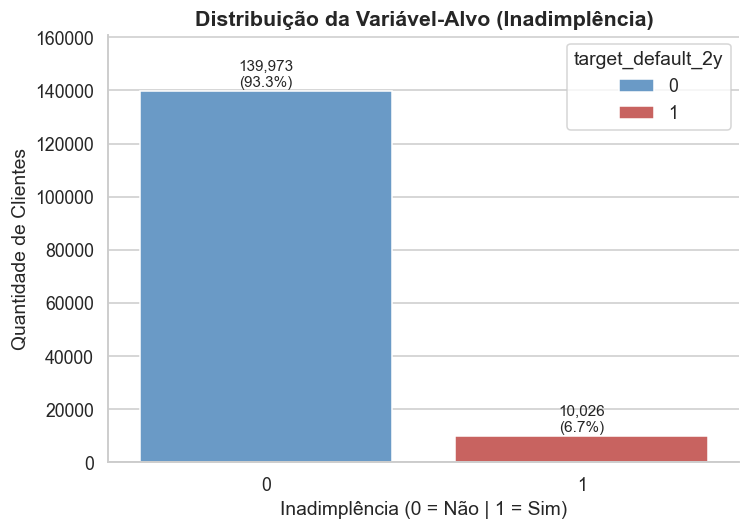

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

# Contagem absoluta
counts = df['target_default_2y'].value_counts().sort_index()
total = counts.sum()
perc = counts / total * 100

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=PALETTE_TARGET,
    hue=counts.index,
    ax=ax
)

# Títulos e labels
ax.set_title('Distribuição da Variável-Alvo (Inadimplência)', fontsize=14, fontweight='bold')
ax.set_xlabel('Inadimplência (0 = Não | 1 = Sim)')
ax.set_ylabel('Quantidade de Clientes')

# Adicionar rótulos com contagem + percentual
for i, (count, p) in enumerate(zip(counts.values, perc.values)):
    ax.text(
        i,
        count + (total * 0.01),  # pequeno offset
        f'{count:,}\n({p:.1f}%)',
        ha='center',
        fontsize=10
    )

# Ajuste visual opcional
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

> **⚠️ Desbalanceamento:** A classe minoritária (inadimplentes) representa apenas ~6,7% da base.  
> Esse desequilíbrio é comum em dados de crédito, mas exige atenção especial na modelagem para evitar que o modelo simplesmente preveja sempre a classe majoritária.
>
> **Estratégias a explorar no notebook de modelagem (`04_balanceamento.ipynb`):**
> - **SMOTE** ou outras abordagens de oversampling da classe minoritária
> - **Class weights** para penalizar erros na classe inadimplente
> - **Undersampling** da classe majoritária (com cautela)
> - Métricas adequadas: **AUC-ROC**, **F1-Score**, **Precision-Recall** em vez de acurácia simples
>
> Documentar esse desequilíbrio nesta etapa é essencial para justificar as escolhas técnicas futuras.

---

## 4. Análise Bivariada — Variáveis vs. Target

Com a variável-alvo compreendida, agora investigamos como cada feature se comporta dentro de cada classe. Essa análise guia a seleção de variáveis e evidencia os principais sinais preditivos.

### 4.1 Variáveis Contínuas vs. Target

In [31]:
def plot_continuous_bivariate(df, column, target='target_default_2y'):
    """
    Boxplot + Violin plot de variável contínua segmentada pelo target.

    Args:
        df (pd.DataFrame): DataFrame com os dados.
        column (str): Variável contínua a ser comparada.
        target (str): Nome da coluna target binária.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    palette = [PALETTE_TARGET[0], PALETTE_TARGET[1]]

    # Boxplot
    sns.boxplot(data=df, x=target, y=column, ax=axes[0], palette=palette, hue=target)
    axes[0].set_title(f'Boxplot: {column}', fontsize=13)
    axes[0].set_xlabel('Inadimplência (0 = Não | 1 = Sim)')
    axes[0].set_ylabel(column)

    # Violin plot
    sns.violinplot(data=df, x=target, y=column, ax=axes[1], inner='quartile', palette=palette, hue=target)
    axes[1].set_title(f'Violin Plot: {column}', fontsize=13)
    axes[1].set_xlabel('Inadimplência (0 = Não | 1 = Sim)')
    axes[1].set_ylabel(column)

    plt.suptitle(f'Distribuição por Classe — {column}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

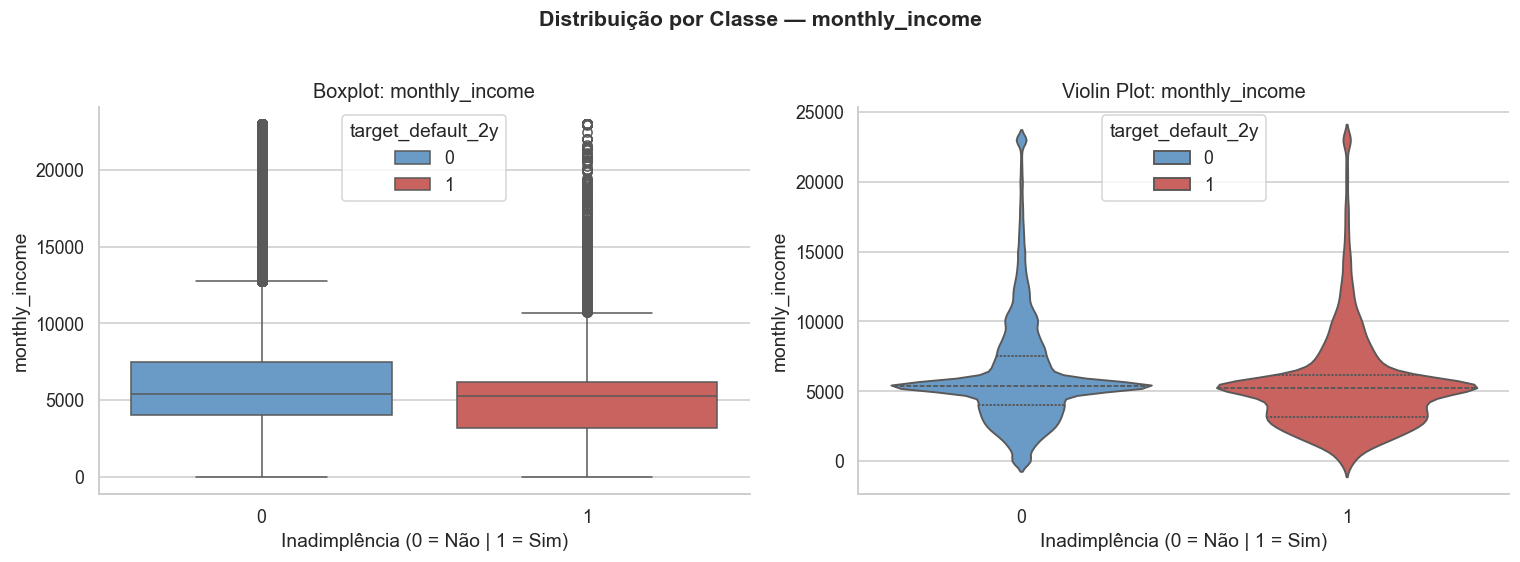

In [32]:
plot_continuous_bivariate(df, 'monthly_income')

> **🔍 Insight:** Clientes inadimplentes apresentam mediana de renda inferior ao grupo adimplente.  
> O violin plot mostra que inadimplentes têm densidade concentrada em rendas mais baixas, enquanto adimplentes exibem distribuição mais espalhada e cauda superior mais longa.  
> **Menor capacidade financeira → maior risco de default.** Variável com potencial preditivo relevante.

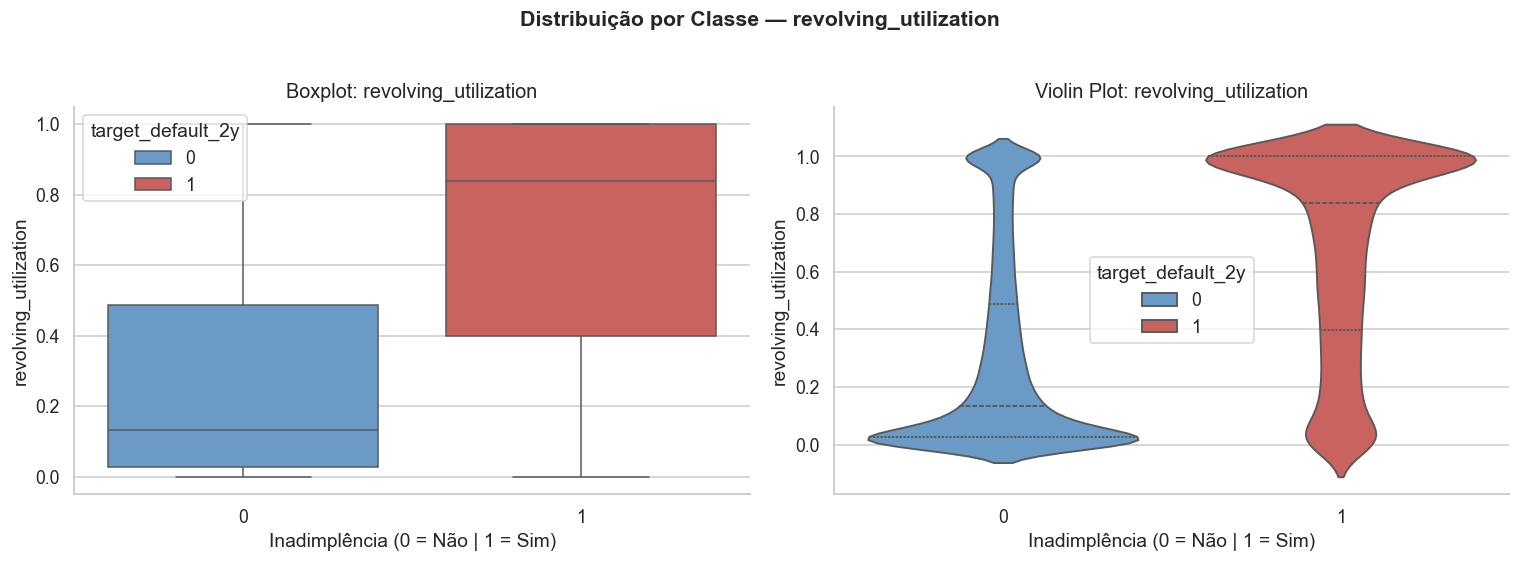

In [33]:
plot_continuous_bivariate(df, 'revolving_utilization')

> **🔍 Insight:** Diferença estrutural clara entre os grupos. Inadimplentes apresentam, em média, utilização de crédito rotativo significativamente mais alta.  
> O violin plot reforça: adimplentes têm densidade concentrada em baixa utilização, enquanto inadimplentes exibem massa maior em valores elevados.  
> **Alta utilização do crédito disponível é um dos sinais mais fortes de estresse financeiro.** Uma das variáveis com maior poder preditivo esperado.

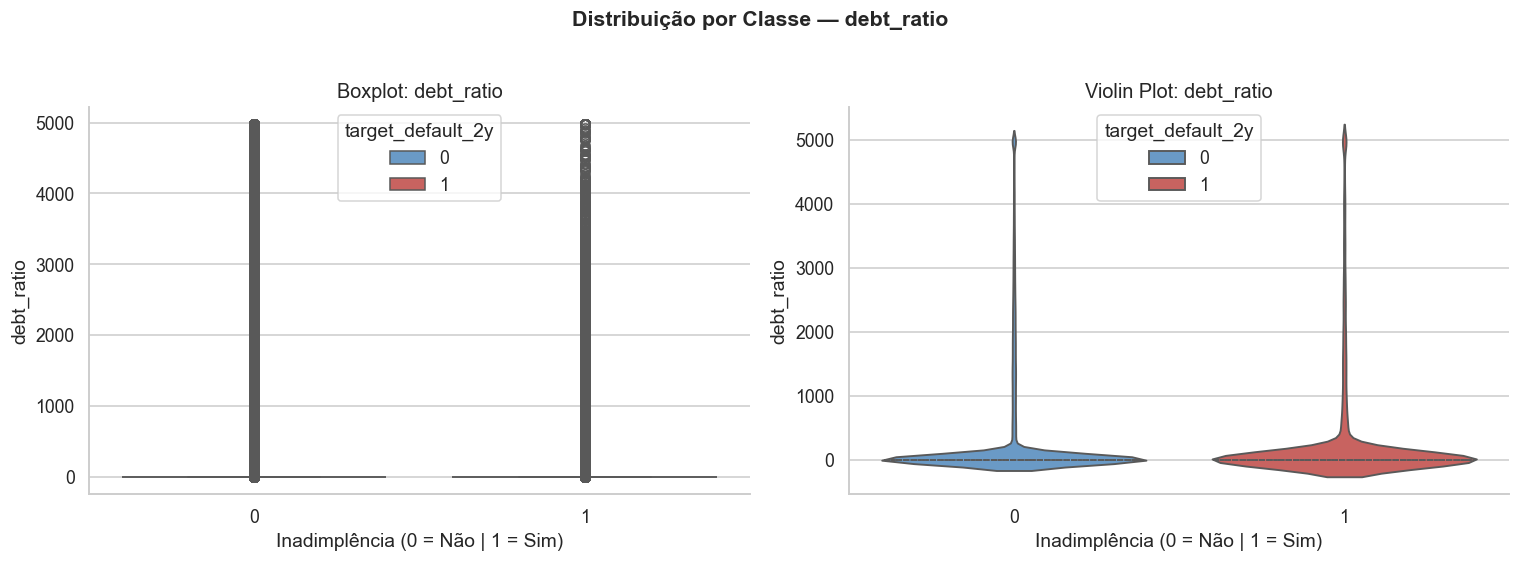

In [34]:
plot_continuous_bivariate(df, 'debt_ratio')

> **🔍 Insight:** Embora ambos os grupos mostrem distribuições assimétricas, inadimplentes tendem a apresentar valores de `debt_ratio` mais elevados.  
> A cauda superior mais longa e os outliers mais extremos entre inadimplentes indicam que comprometimento desproporcional da renda aumenta o risco de default.

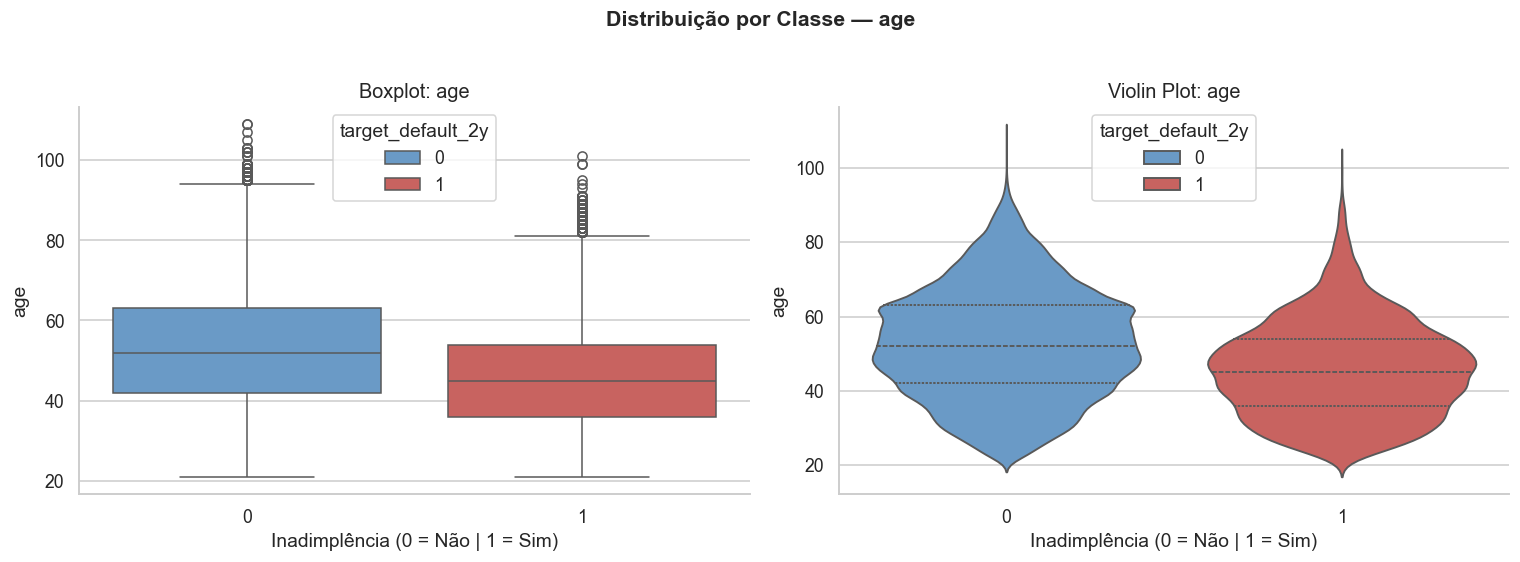

In [35]:
plot_continuous_bivariate(df, 'age')

> **🔍 Insight:** Clientes inadimplentes são, em média, ligeiramente mais jovens.  
> O sinal é menos pronunciado do que variáveis financeiras — mas é coerente: indivíduos mais jovens tendem a ter menor histórico de crédito e maior variabilidade de renda.

---

### 4.2 Variáveis Discretas vs. Target

In [36]:
def compare_discrete_distribution(df, column, target='target_default_2y', title_name=None):
    """
    Compara a distribuição de uma variável discreta entre classes do target.
    Gera frequência absoluta e proporção relativa lado a lado.

    Args:
        df (pd.DataFrame): DataFrame com os dados.
        column (str): Variável discreta a ser comparada.
        target (str): Nome da coluna target binária.
        title_name (str, optional): Rótulo customizado.
    """
    label_name = title_name if title_name else column

    freq = df.groupby([target, column]).size().reset_index(name='count')
    freq['percent'] = freq.groupby(target)['count'].transform(lambda x: x / x.sum() * 100)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Frequência absoluta
    sns.barplot(data=freq, x=column, y='count', hue=target,
                ax=axes[0], palette=PALETTE_TARGET)
    axes[0].set_title(f'Volume Absoluto: {label_name}', fontsize=13, pad=10)
    axes[0].set_ylabel('Quantidade de Clientes')
    axes[0].set_xlabel(label_name)
    axes[0].legend(title='Inadimplente', labels=['Não (0)', 'Sim (1)'])

    # Proporção relativa (o mais importante para o insight)
    sns.barplot(data=freq, x=column, y='percent', hue=target,
                ax=axes[1], palette=PALETTE_TARGET)
    axes[1].set_title(f'Proporção Relativa: {label_name} (%)', fontsize=13, pad=10)
    axes[1].set_ylabel('Percentual dentro do grupo (%)')
    axes[1].set_xlabel(label_name)
    axes[1].get_legend().remove()

    plt.suptitle(f'Comparação por Classe — {label_name}', fontsize=14, fontweight='bold', y=1.02)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

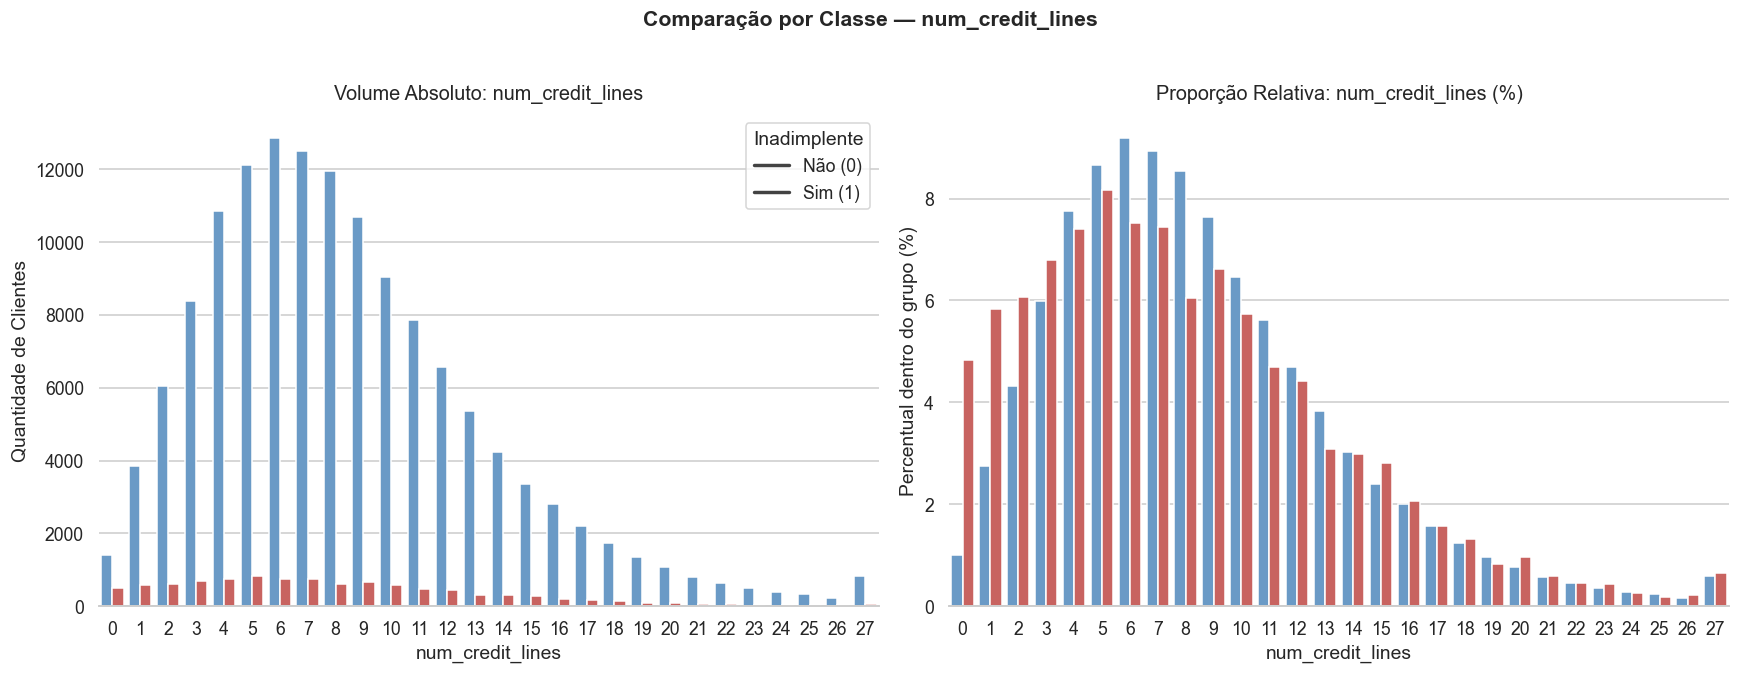

In [37]:
compare_discrete_distribution(df, 'num_credit_lines')

> **🔍 Insight:** Distribuições praticamente idênticas entre adimplentes e inadimplentes.  
> `num_credit_lines` **não é uma variável fortemente discriminativa** — o volume total de linhas abertas não diferencia bem o comportamento de pagamento.

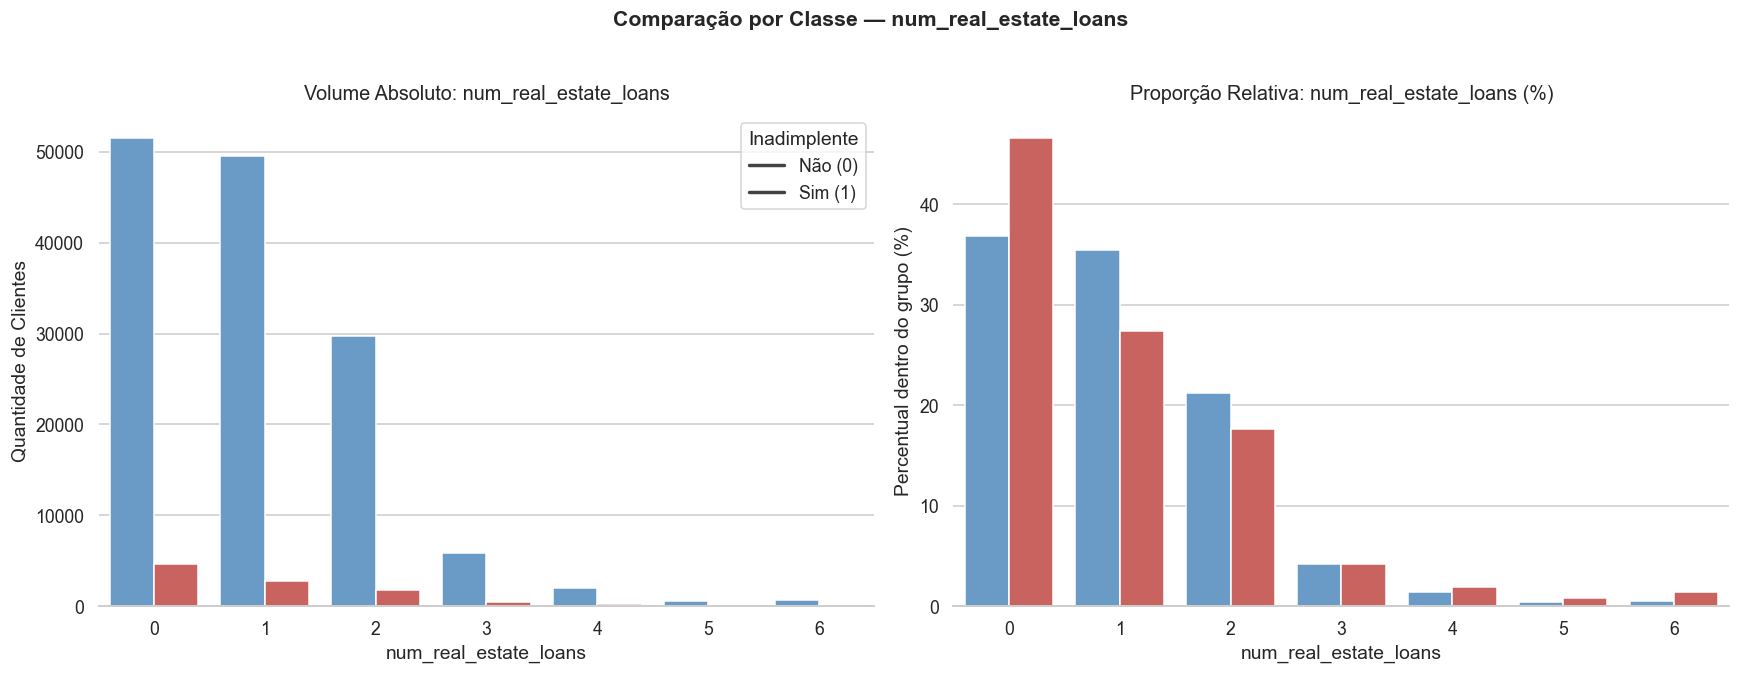

In [38]:
compare_discrete_distribution(df, 'num_real_estate_loans')

> **🔍 Insight:** Distribuição quase sobreposta entre os grupos. A maioria possui 0 ou 1 empréstimo imobiliário em ambas as classes.  
> Variável com **baixo poder discriminativo** — reflete mais o perfil geral da base do que risco diferencial.

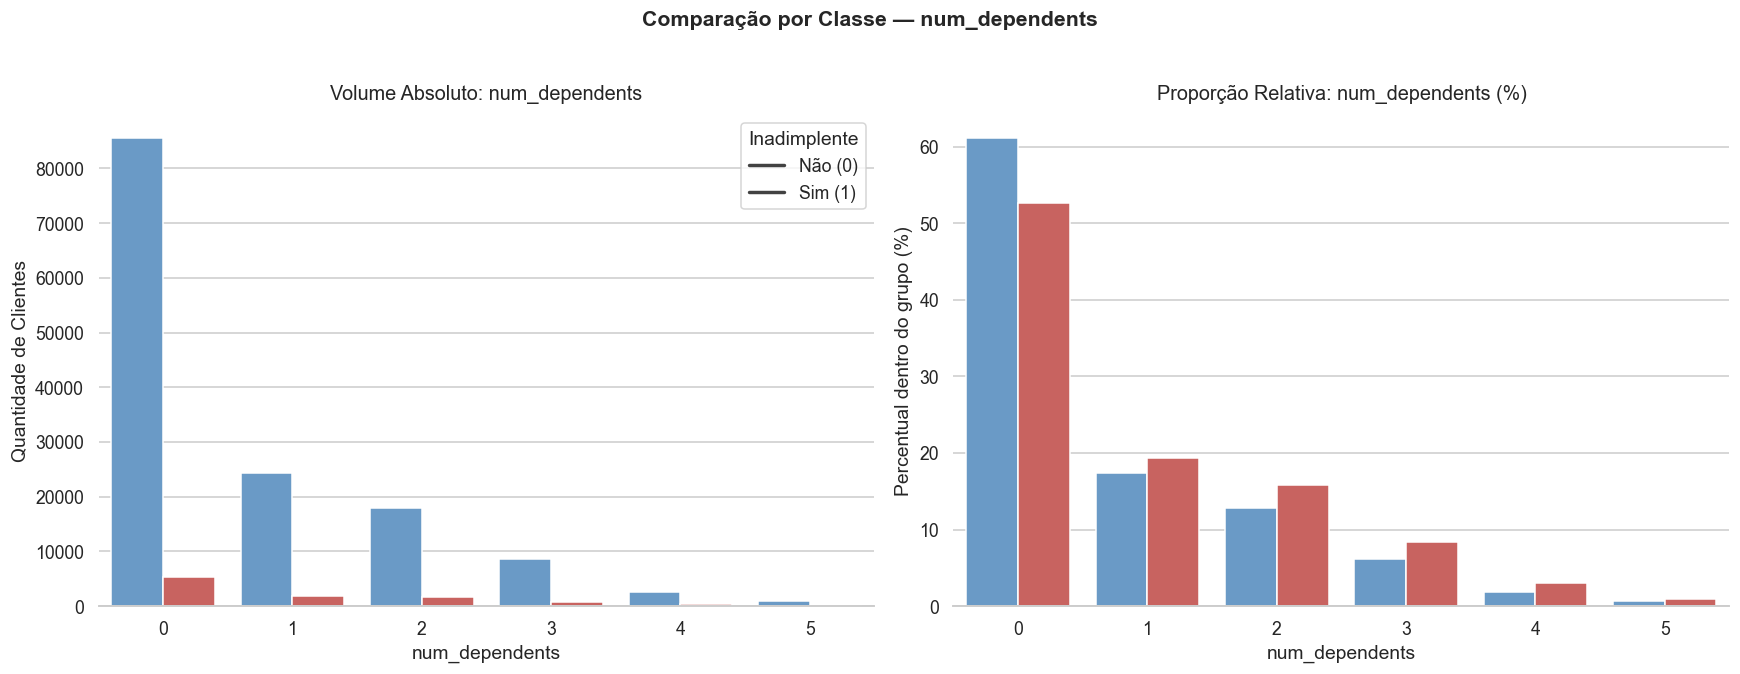

In [39]:
compare_discrete_distribution(df, 'num_dependents')

> **🔍 Insight:** Distribuições muito semelhantes entre os grupos. Pequenas diferenças em categorias com 3+ dependentes são frágeis estatisticamente.  
> `num_dependents` **não se mostra discriminativo** nesta análise visual — pode contribuir marginalmente na modelagem.

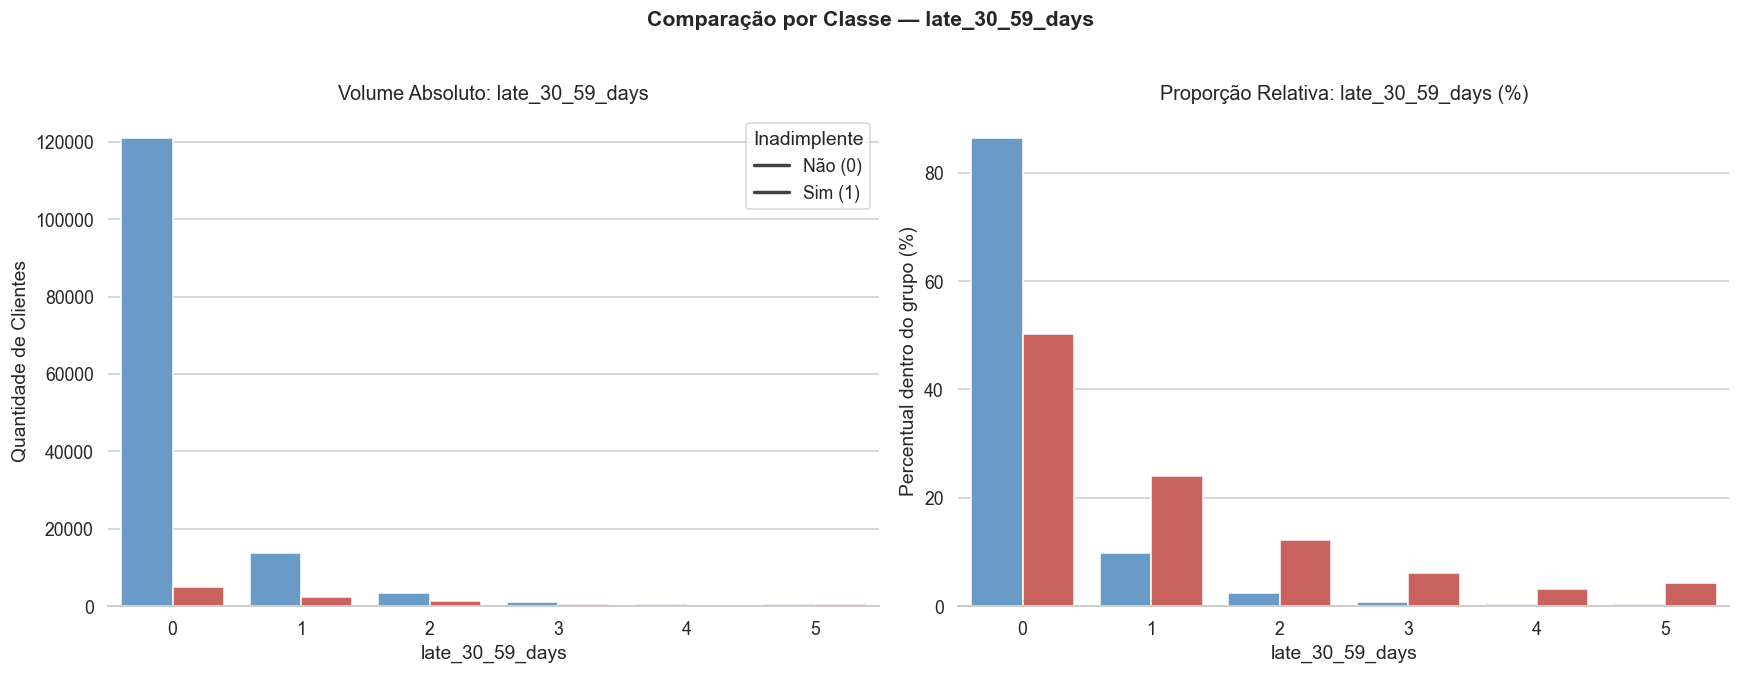

In [40]:
compare_discrete_distribution(df, 'late_30_59_days')

> **🔍 Insight:** Sinal claro de risco. Dentro do grupo inadimplente, a proporção de clientes com valores acima de 0 é visivelmente maior.  
> Atrasos moderados no passado são preditores fortes de inadimplência futura — mesmo ocorrências únicas são informativamente relevantes.

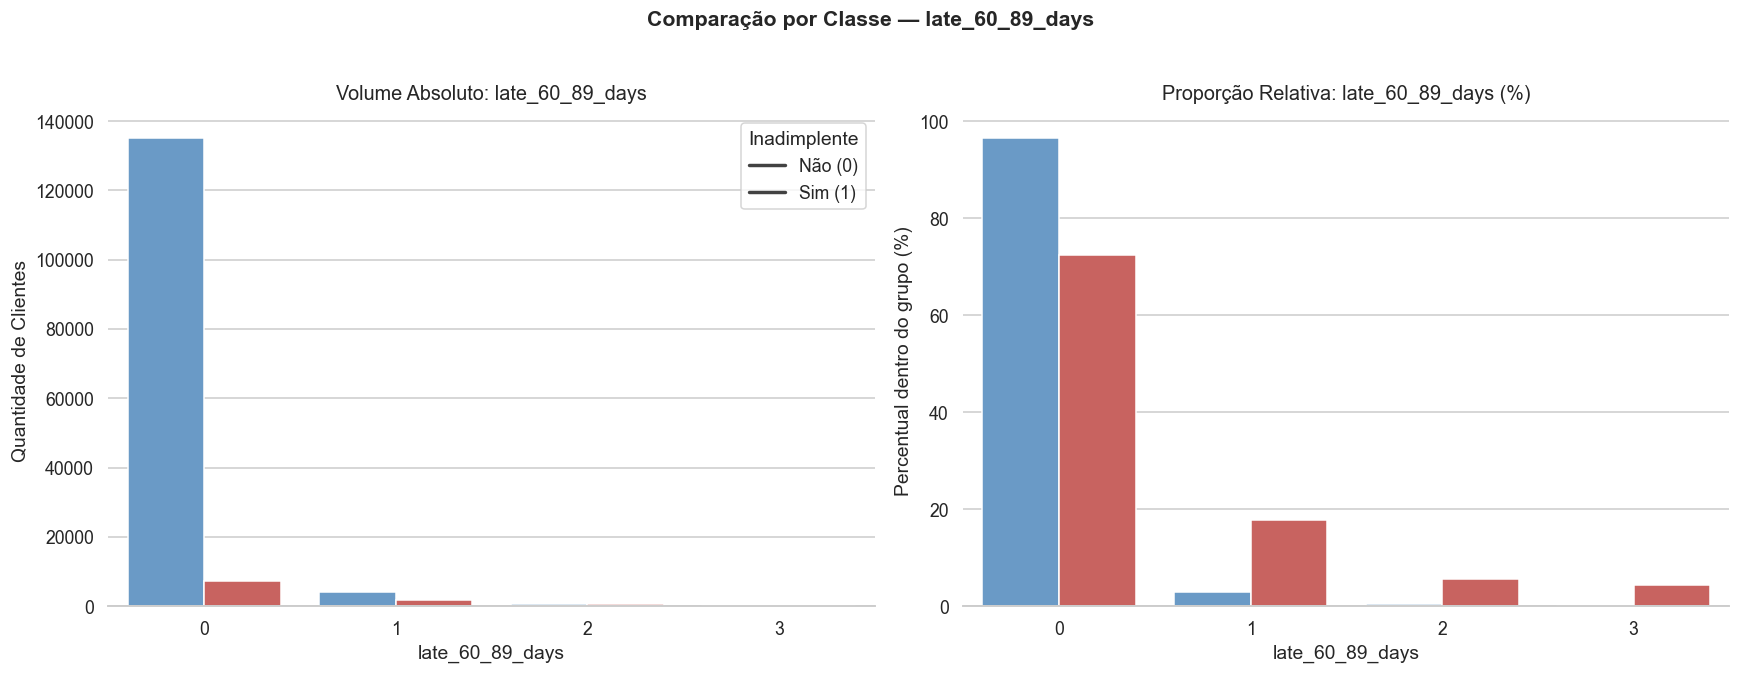

In [41]:
compare_discrete_distribution(df, 'late_60_89_days')

> **🔍 Insight:** Diferença ainda mais pronunciada do que em `late_30_59_days`. Nas categorias 1, 2 e 3, inadimplentes aparecem com frequência relativa muito superior.  
> **Padrão típico de variáveis de histórico de atraso:** mesmo ocorrências raras carregam peso discriminativo alto.

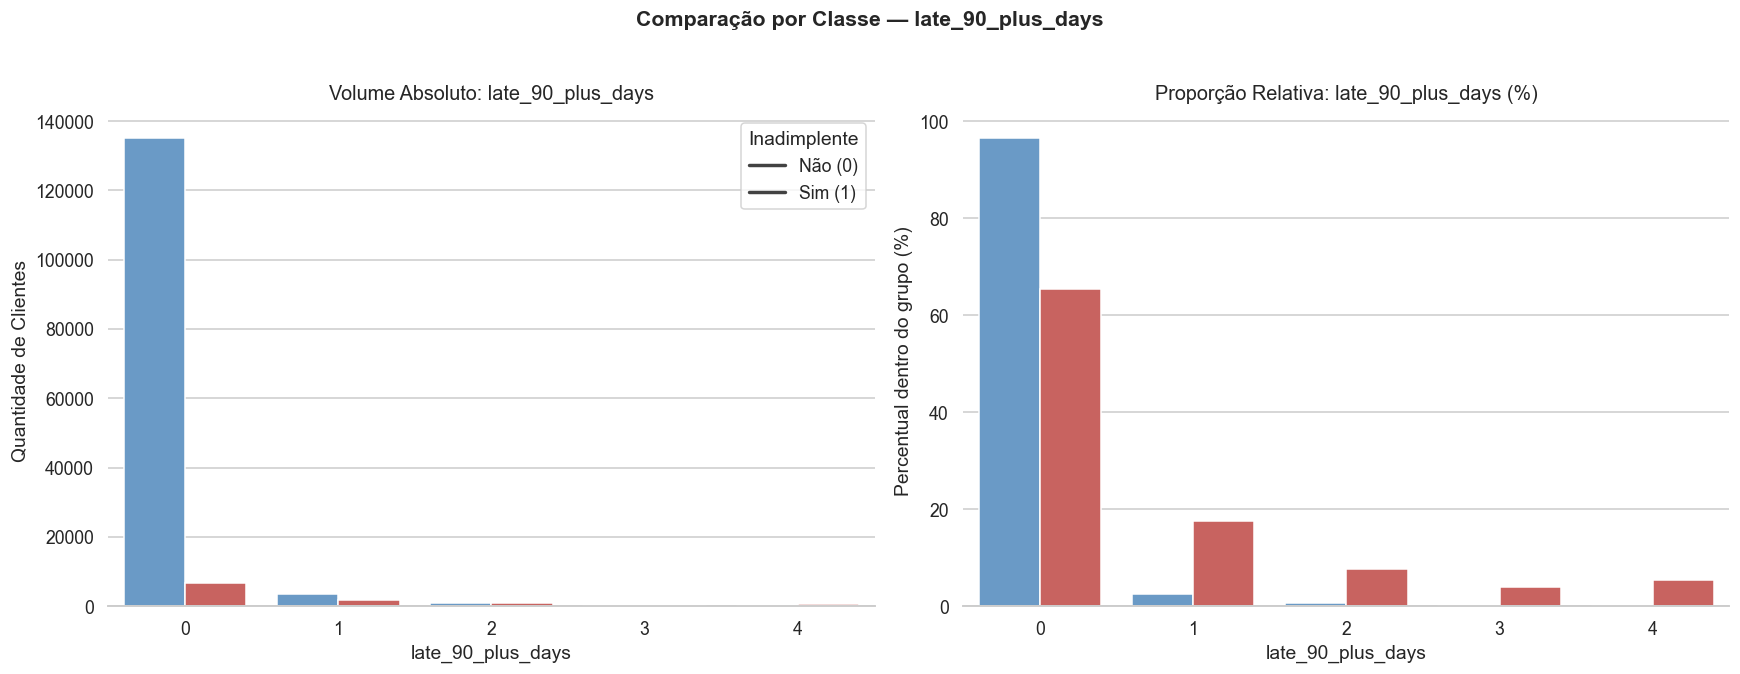

In [42]:
compare_discrete_distribution(df, 'late_90_plus_days')

> **🔍 Insight:** **O sinal mais forte entre todas as variáveis discretas.** A diferença proporcional entre inadimplentes e adimplentes nas categorias acima de 0 é extremamente marcante.  
> Atrasos superiores a 90 dias representam inadimplência severa e são altamente preditivos de default futuro. Esta deve ser uma das features mais importantes do modelo.

---

## 5. Correlações e Estrutura de Dependência

Nesta seção investigamos as relações lineares e monotônicas entre variáveis, e identificamos potencial multicolinearidade — que pode impactar modelos interpretativos.

### 5.1 Matriz de Correlação de Pearson

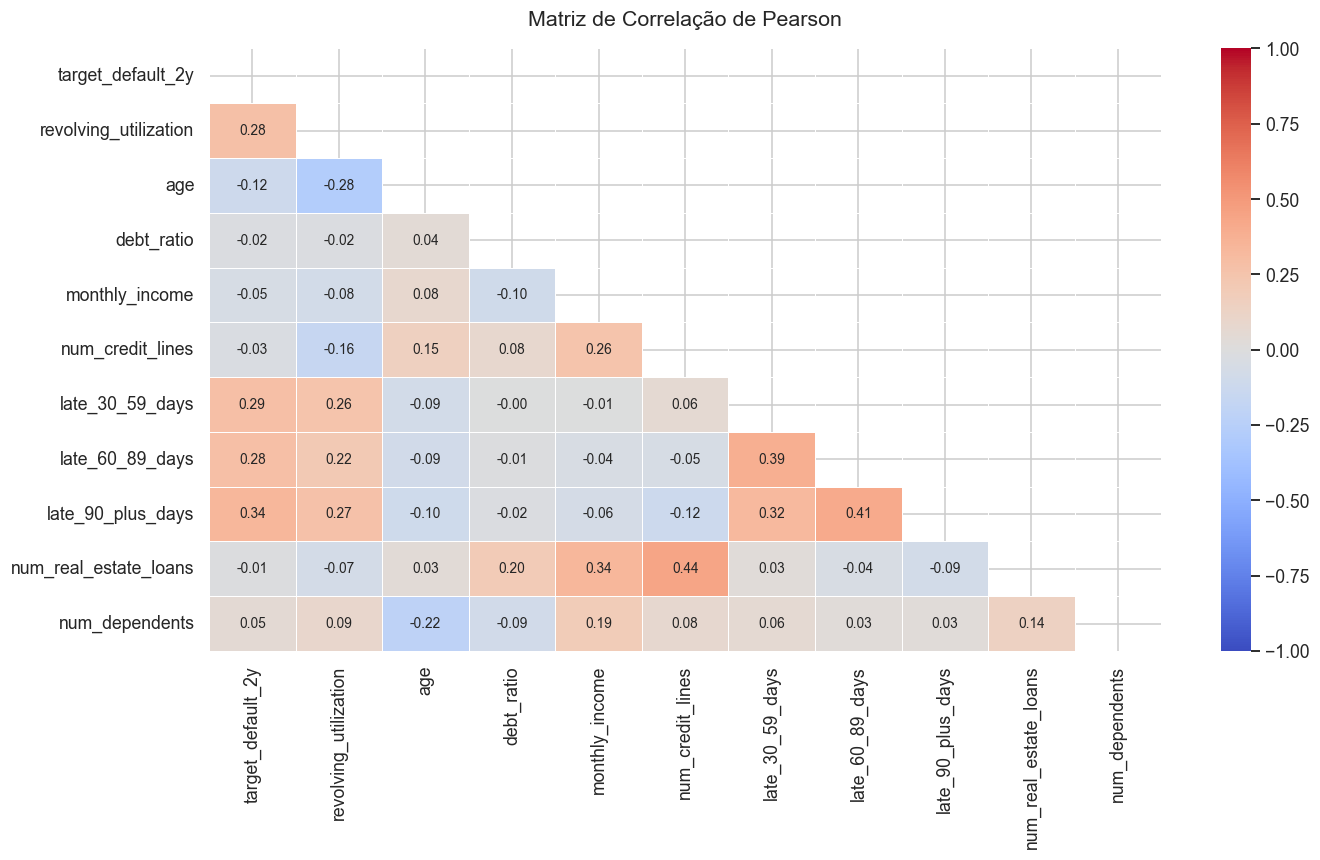

In [43]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(13, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # Exibe apenas triângulo inferior
sns.heatmap(corr, mask=mask, cmap=PALETTE_HEATMAP, annot=True,
            fmt='.2f', linewidths=0.4, center=0, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Matriz de Correlação de Pearson', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> **🔍 Insights da matriz:**
> - `late_90_plus_days`, `late_30_59_days` e `late_60_89_days` são as variáveis com maior correlação positiva com o target.
> - **Alta colinearidade entre as variáveis de atraso** — o que é esperado, pois um cliente que atrasa >90 dias provavelmente também atrasou nas faixas anteriores.
> - `revolving_utilization` apresenta correlação relevante com o target apesar de sua natureza contínua.
> - `age` e `monthly_income` possuem correlação negativa fraca — clientes mais velhos e com maior renda tendem a ser ligeiramente menos inadimplentes.

### 5.2 Correlação com o Target — Pearson vs. Spearman

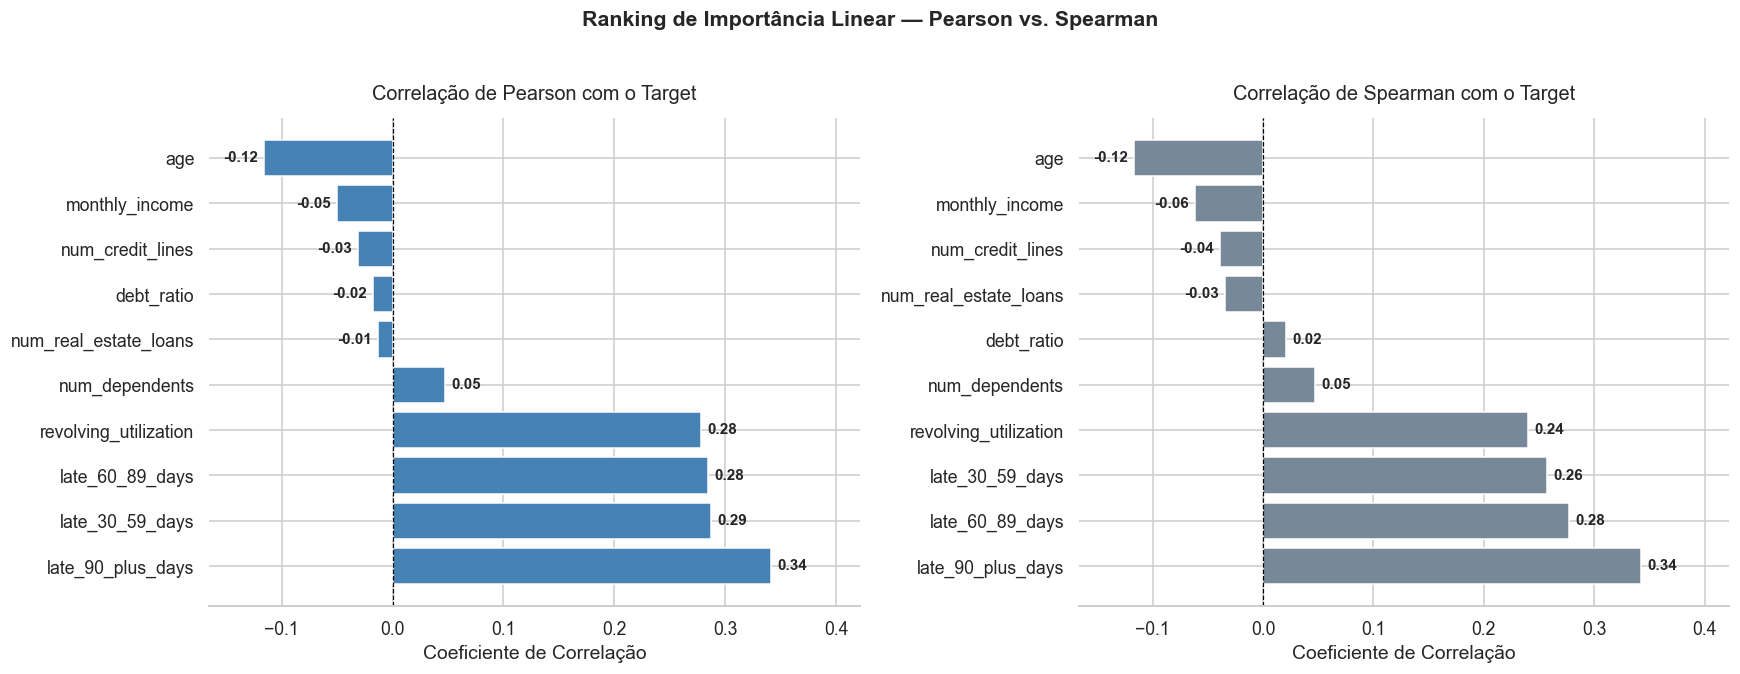

In [44]:
target_pearson  = corr['target_default_2y'].drop('target_default_2y').sort_values(ascending=False)
target_spearman = df.corr(method='spearman', numeric_only=True)['target_default_2y'] \
                    .drop('target_default_2y').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, values, title, color in zip(
    axes,
    [target_pearson, target_spearman],
    ['Correlação de Pearson com o Target', 'Correlação de Spearman com o Target'],
    [PALETTE_MAIN, 'lightslategray']
):
    bars = ax.barh(values.index, values.values, color=color)
    ax.bar_label(bars, padding=4, fmt='%.2f', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Coeficiente de Correlação')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlim(values.min() - 0.05, values.max() + 0.08)
    sns.despine(ax=ax, left=True)

plt.suptitle('Ranking de Importância Linear — Pearson vs. Spearman', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **🔍 Insights:**
> - **Top preditores (Pearson):** `late_90_plus_days` (≈0.34), `late_30_59_days` (≈0.29), `late_60_89_days` (≈0.28), `revolving_utilization` (≈0.28).
> - **Spearman confirma a ordem** — as correlações monotônicas são consistentes com as lineares, reforçando que os sinais não são artefatos de outliers.
> - **Sinais fracos/negativos:** `age`, `monthly_income`, `num_credit_lines`, `debt_ratio` têm correlações lineares fracas, mas podem contribuir em modelos não-lineares.

### 5.3 Dendrograma de Agrupamento

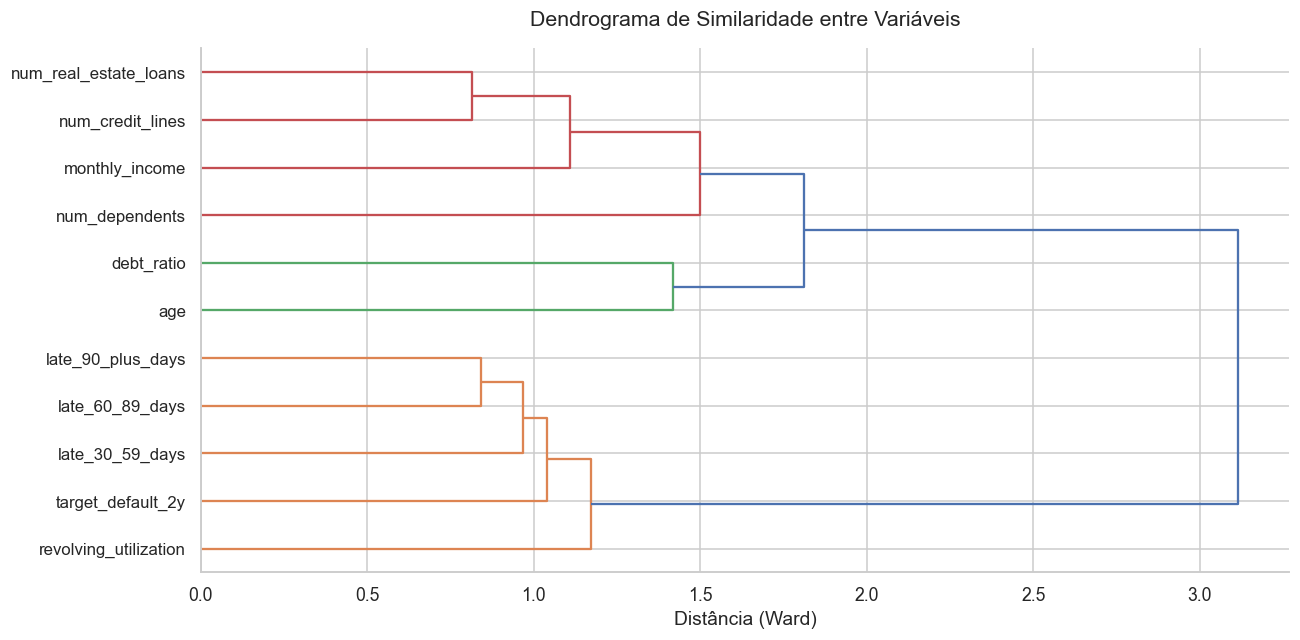

In [45]:
plt.figure(figsize=(12, 6))
linked = linkage(corr, method='ward')
dendrogram(linked, labels=corr.columns.tolist(), orientation='right',
           leaf_font_size=11, color_threshold=1.5)
plt.title('Dendrograma de Similaridade entre Variáveis', fontsize=14, pad=15)
plt.xlabel('Distância (Ward)')
plt.tight_layout()
plt.show()

> **🔍 Insights:**
> - **Cluster 1:** `late_30_59_days`, `late_60_89_days`, `late_90_plus_days` — alta similaridade entre si; redundância informacional confirmada.
> - **Cluster 2:** `num_real_estate_loans`, `num_credit_lines`, `monthly_income` — agrupadas pelo perfil patrimonial do cliente.
> - Em modelos lineares, a colinearidade entre as variáveis de atraso pode inflar VIF; em modelos baseados em árvores o impacto é menor.

---

## 6. Interações entre Variáveis de Atraso

As variáveis de atraso são altamente correlacionadas entre si. Aqui investigamos se a combinação delas amplifica o sinal de risco além do efeito individual de cada uma.

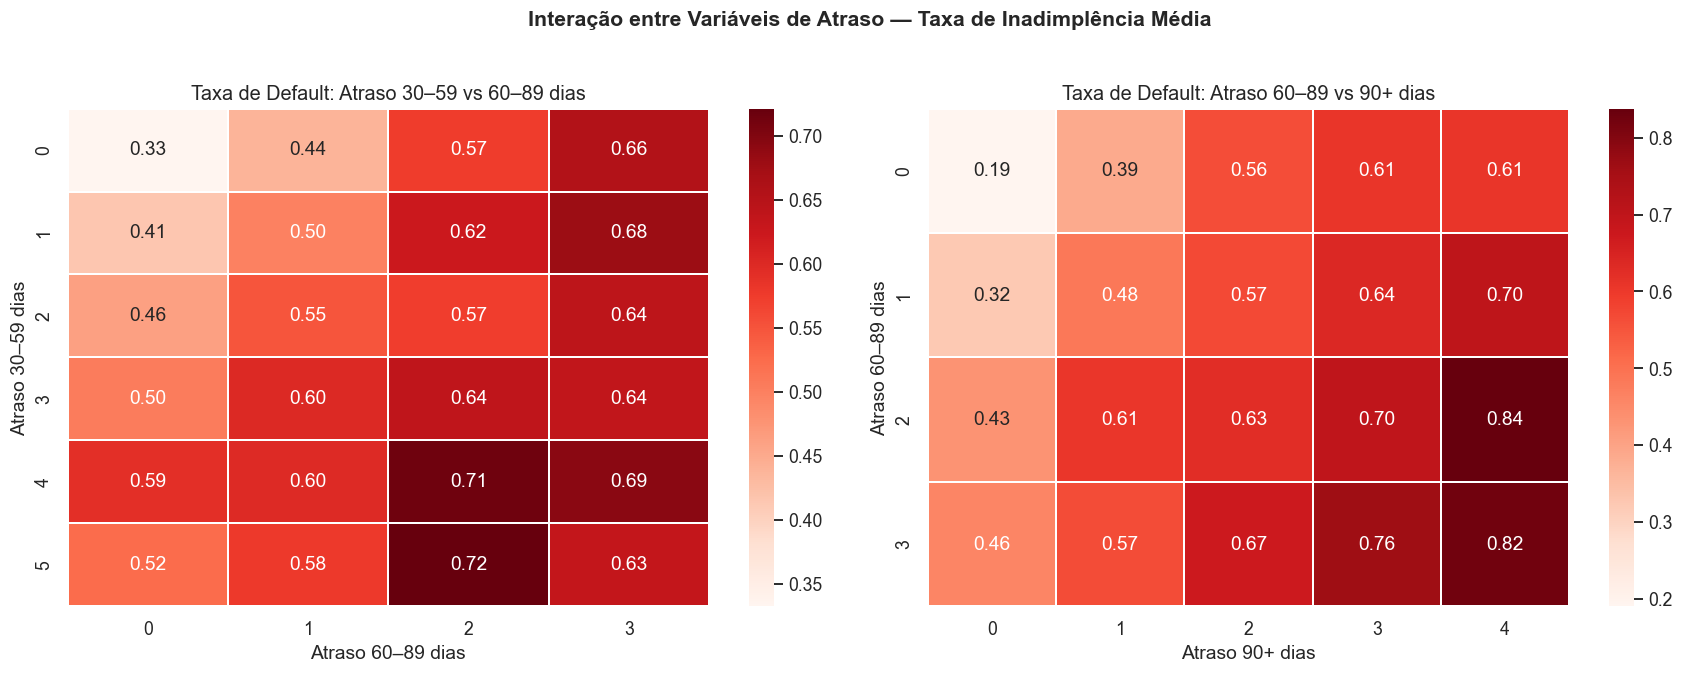

In [46]:
delay_cols = ['late_30_59_days', 'late_60_89_days', 'late_90_plus_days']
interaction = df.groupby(delay_cols)['target_default_2y'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 30-59 vs 60-89
pivot1 = interaction.pivot_table(index='late_30_59_days',
                                  columns='late_60_89_days',
                                  values='target_default_2y')
sns.heatmap(pivot1, annot=True, fmt='.2f', cmap='Reds', ax=axes[0], linewidths=0.3)
axes[0].set_title('Taxa de Default: Atraso 30–59 vs 60–89 dias', fontsize=13)
axes[0].set_xlabel('Atraso 60–89 dias')
axes[0].set_ylabel('Atraso 30–59 dias')

# 60-89 vs 90+
pivot2 = interaction.pivot_table(index='late_60_89_days',
                                  columns='late_90_plus_days',
                                  values='target_default_2y')
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='Reds', ax=axes[1], linewidths=0.3)
axes[1].set_title('Taxa de Default: Atraso 60–89 vs 90+ dias', fontsize=13)
axes[1].set_xlabel('Atraso 90+ dias')
axes[1].set_ylabel('Atraso 60–89 dias')

plt.suptitle('Interação entre Variáveis de Atraso — Taxa de Inadimplência Média',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **🔍 Insights:**
> - A taxa de inadimplência cresce com o aumento de ambas as variáveis de atraso — há **efeito de interação positiva**.
> - A combinação de atrasos em múltiplas faixas amplifica o risco além do efeito isolado de cada variável.
> - O salto mais acentuado ocorre na transição de 0→1 ocorrência — qualquer episódio de atraso já é sinal relevante.

### 6.1 Interações com Variáveis Demográficas

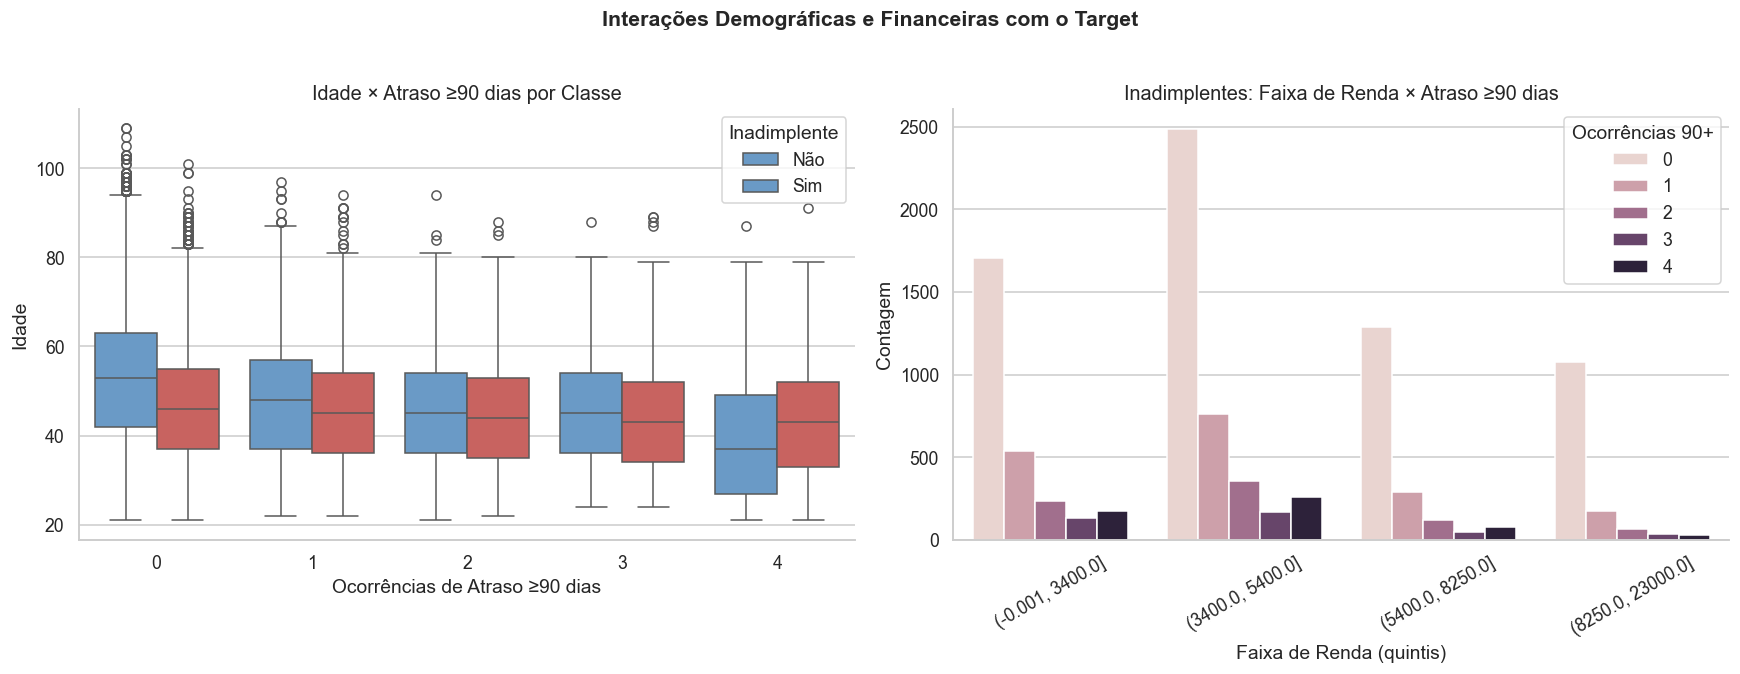

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Idade vs Atraso 90+
sns.boxplot(data=df, x='late_90_plus_days', y='age',
            hue='target_default_2y', palette=PALETTE_TARGET, ax=axes[0])
axes[0].set_title('Idade × Atraso ≥90 dias por Classe', fontsize=13)
axes[0].set_xlabel('Ocorrências de Atraso ≥90 dias')
axes[0].set_ylabel('Idade')
axes[0].legend(title='Inadimplente', labels=['Não', 'Sim'])

# Renda por faixa vs Atraso 90+
df_temp = df.copy()
df_temp['income_bin'] = pd.qcut(df['monthly_income'], q=5, duplicates='drop').astype(str)
income_order = sorted(df_temp['income_bin'].unique(),
                      key=lambda x: float(x.split(',')[0].replace('(','').replace('[','')))

sns.countplot(data=df_temp[df_temp['target_default_2y'] == 1],
              x='income_bin', hue='late_90_plus_days',
              order=income_order, ax=axes[1])
axes[1].set_title('Inadimplentes: Faixa de Renda × Atraso ≥90 dias', fontsize=13)
axes[1].set_xlabel('Faixa de Renda (quintis)')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Ocorrências 90+', bbox_to_anchor=(1, 1))

plt.suptitle('Interações Demográficas e Financeiras com o Target',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **🔍 Insights:**
> - Clientes inadimplentes com atrasos severos (90+) tendem a ser mais jovens do que adimplentes com a mesma quantidade de ocorrências.
> - Entre os inadimplentes, a maior concentração de atrasos >90 dias ocorre nas **faixas de renda mais baixas** — evidência de que renda e histórico de atraso interagem no perfil de risco.

---

## 7. Conclusões e Direcionamentos para a Modelagem

### 📊 Principais Achados

| Dimensão | Principais Variáveis | Sinal |
|---|---|---|
| Histórico de atraso | `late_90_plus_days`, `late_60_89_days`, `late_30_59_days` | ⬆️ Alta utilização → maior risco |
| Uso de crédito | `revolving_utilization` | ⬆️ Quanto maior a utilização, maior o risco |
| Capacidade financeira | `monthly_income`, `debt_ratio` | ⬇️ Menor renda / maior comprometimento → maior risco |
| Perfil demográfico | `age` | ⬇️ Clientes mais jovens com leve tendência a maior risco |
| Baixa discriminação | `num_credit_lines`, `num_real_estate_loans`, `num_dependents` | ≈ Sinal fraco ou ausente |

> 📁 Próximo notebook: `03_feature_engineering.ipynb`